In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
production_df = pd.read_excel(r'data/CCI_scenarios/Extracted_data.xlsx', sheet_name='Production')

In [3]:
production_df

,Scenario,Year,Unit,Cobalt,Copper,Graphite,Lithium,Neodymium,Nickel
0,Existing production,2020,kt,3.2,530.9,8.2,0.0,0.0,154.4
1,Existing production,2021,kt,3.8,488.5,4.2,0.2,0.0,138.9
2,Existing production,2022,kt,2.5,460.4,13.6,3.5,0.0,126.6
3,Existing production,2023,kt,4.8,404.0,4.2,16.7,0.0,186.8
4,Existing production,2024,kt,3.4,478.9,6.3,39.9,0.0,134.6
5,Existing production,2025,kt,3.5,483.9,0.0,37.6,0.0,154.6
6,Existing production,2026,kt,3.5,475.6,0.0,40.0,0.0,158.5
7,Existing production,2027,kt,4.2,495.0,0.0,41.7,0.0,158.5
8,Existing production,2028,kt,4.2,461.1,0.0,40.3,0.0,154.8
9,Existing production,2029,kt,3.9,348.3,0.0,37.9,0.0,152.1


In [4]:
df = production_df

In [9]:
df.to_csv(r'production_df.csv', index=False)

In [5]:
df_long = df.melt(
        id_vars=["Scenario", "Year", "Unit"],
        var_name="Metal",
        value_name="Value"
    )

    # --- Clean ordering ---
metals = df_long["Metal"].unique().tolist()
df_long["Metal"] = pd.Categorical(df_long["Metal"], categories=metals, ordered=True)

In [6]:
df_long

,Scenario,Year,Unit,Metal,Value
0,Existing production,2020,kt,Cobalt,3.2
1,Existing production,2021,kt,Cobalt,3.8
2,Existing production,2022,kt,Cobalt,2.5
3,Existing production,2023,kt,Cobalt,4.8
4,Existing production,2024,kt,Cobalt,3.4
...,...,...,...,...,...
247,Production potential,2036,kt,Nickel,352.8
248,Production potential,2037,kt,Nickel,329.5
249,Production potential,2038,kt,Nickel,298.9
250,Production potential,2039,kt,Nickel,306.8


In [7]:
color_map = {
    'Copper': '#8c510a',
    'Nickel': '#d8b365',
    'Graphite': '#f6e8c3',
    'Cobalt': '#c7eae5',
    'Lithium': '#5ab4ac',
    'Neodymium': '#01665e'
}

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_metal_scenarios_panels(df, color_map,
                                figsize=(10, 7), dpi=350, savepath=None):
    """
    Create 3-panel Matplotlib figure:
    - Top: line chart across both scenarios (solid/dashed lines)
    - Bottom: 2 stacked area charts (one per scenario, same y scale)
    """

    import numpy as np
    import matplotlib.pyplot as plt

    df_long = df.melt(
        id_vars=["Scenario", "Year", "Unit"],
        var_name="Metal",
        value_name="Value"
    )

    metals = df_long["Metal"].unique().tolist()
    scenarios = df_long["Scenario"].unique().tolist()
    unit = df_long["Unit"].iloc[0]

    # Auto line styles
    if len(scenarios) == 2:
        scenario_styles = {
            scenarios[0]: {"linestyle": "-", "label": f"{scenarios[0]}"},
            scenarios[1]: {"linestyle": "--", "label": f"{scenarios[1]}"}
        }
    else:
        scenario_styles = {s: {"linestyle": "-", "label": s} for s in scenarios}

    # --- Figure setup ---
    fig = plt.figure(figsize=figsize, dpi=dpi)
    gs = fig.add_gridspec(2, 2, height_ratios=[2, 1])
    ax_top = fig.add_subplot(gs[0, :])
    ax_bottom_left = fig.add_subplot(gs[1, 0], sharex=ax_top)
    ax_bottom_right = fig.add_subplot(gs[1, 1], sharex=ax_top)

    # =======================================================
    # 1️⃣ Top panel: line chart
    # =======================================================
    for metal in metals:
        for scen in scenarios:
            dsub = df_long[(df_long["Metal"] == metal) & (df_long["Scenario"] == scen)]
            ax_top.plot(
                dsub["Year"],
                dsub["Value"],
                color=color_map.get(metal, "#cccccc"),
                linestyle=scenario_styles[scen]["linestyle"],
                linewidth=1.8,
                alpha=0.9,
            )

    ax_top.set_title("Production by metal and scenario", fontsize=12, fontweight="bold")
    ax_top.set_ylabel(f"Production ({unit})", fontsize=10)
    #ax_top.grid(True, linestyle="--", alpha=0.3)
    ax_top.tick_params(labelsize=9)
    ax_top.set_xlim(df_long["Year"].min(), df_long["Year"].max())
    ax_top.set_ylim(bottom=0)


    xticks = np.arange(df_long["Year"].min(), df_long["Year"].max() + 1, 5)
    ax_top.set_xticks(xticks)

    # Legend for scenario line styles
    scen_handles = [
        plt.Line2D([0], [0], color="black",
                   linestyle=scenario_styles[s]["linestyle"],
                   label=scenario_styles[s]["label"]) for s in scenarios
    ]
    ax_top.legend(handles=scen_handles, loc="upper left", fontsize=11, frameon=False)

    # =======================================================
    # 2️⃣ Bottom panels: stacked areas
    # =======================================================
    bottom_axes = [ax_bottom_left, ax_bottom_right]
    y_max = 0

    # find global y limit first
    for scen in scenarios:
        d_scen = df_long[df_long["Scenario"] == scen]
        pivot = d_scen.pivot_table(index="Year", columns="Metal", values="Value",
                                   aggfunc="sum", fill_value=0)
        y_max = max(y_max, pivot.sum(axis=1).max())

    # plot each scenario
    for ax, scen in zip(bottom_axes, scenarios):
        d_scen = df_long[df_long["Scenario"] == scen]
        pivot = d_scen.pivot_table(index="Year", columns="Metal",
                                   values="Value", aggfunc="sum", fill_value=0)
        cols = [color_map.get(c, "#cccccc") for c in pivot.columns]
        ax.stackplot(pivot.index, pivot.T, labels=pivot.columns, colors=cols, alpha=0.9)
        ax.set_title(scen, fontsize=11, fontweight="bold")
        ax.set_ylabel(f"Production ({unit})", fontsize=9)
        #ax.grid(True, linestyle="--", alpha=0.3)
        ax.tick_params(labelsize=9)
        ax.set_xticks(xticks)
        #ax.set_xlabel("Year", fontsize=9)
        ax.set_ylim(0, y_max * 1.05)  # unified y scale + small headroom
        ax.set_yticks([y for y in ax.get_yticks() if y != 0])


    for a in [ax_top, ax_bottom_left, ax_bottom_right]:
        a.set_yticks([y for y in a.get_yticks() if y != 0])

    # =======================================================
    # 3️⃣ Shared legend (metals)
    # =======================================================
    handles, labels = ax_bottom_right.get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center",
               bbox_to_anchor=(0.5, 0.02),
               ncol=min(len(labels), 6),
               fontsize=10, frameon=False)

    # =======================================================
    # Layout
    # =======================================================
    plt.subplots_adjust(hspace=0.35, bottom=0.13, top=0.93, wspace=0.25)
    #fig.suptitle("Metal production scenarios comparison", fontsize=14, fontweight="bold")

    if savepath:
        fig.savefig(f"{savepath}.png", bbox_inches="tight")
        fig.savefig(f"{savepath}.svg", bbox_inches="tight")
        print(f"✅ Saved to {savepath}.png and .svg")

    plt.show()


✅ Saved to results/production_scenario.png and .svg


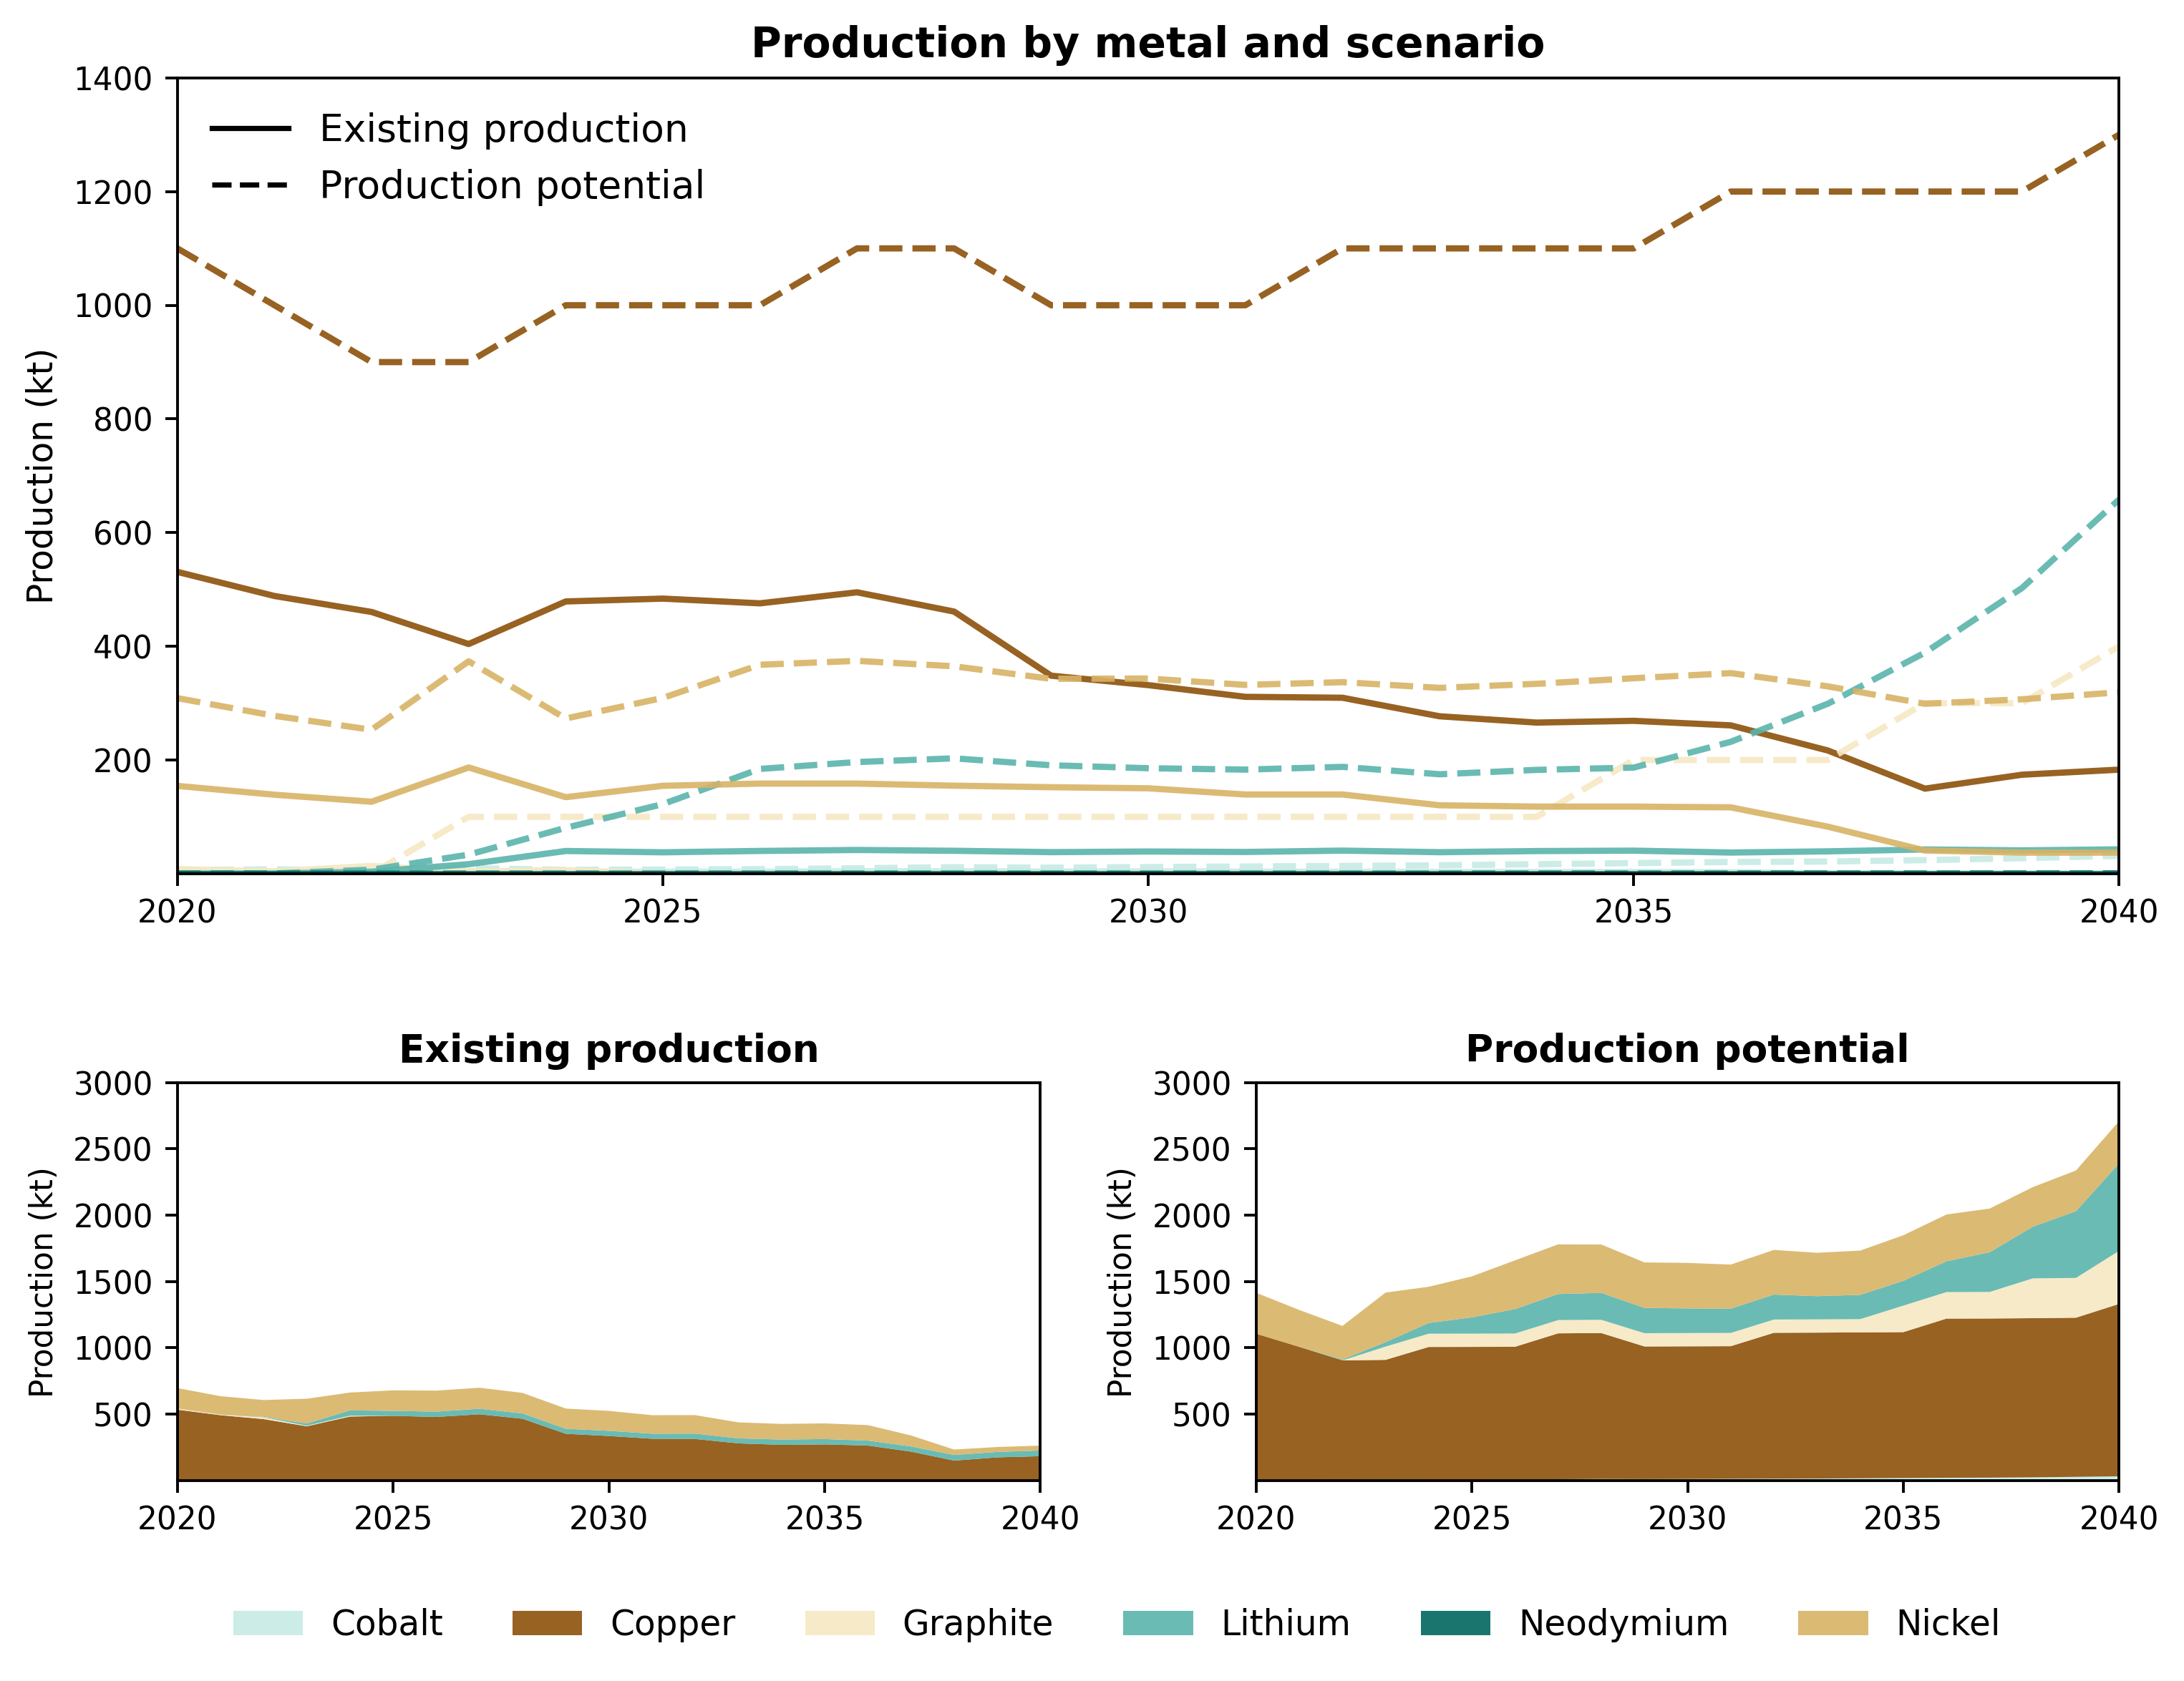

In [54]:
plot_metal_scenarios_panels(production_df, color_map, savepath="results/production_scenario")